# Medical Insurance Cost Prediction

This project predicts medical insurance charges using machine learning based on user details such as age, sex, BMI, number of children, smoking status, and region.

## Objective

The objective is to build a regression model that estimates medical insurance cost based on personal and health-related features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [2]:
insurance_dataset = pd.read_csv("data/insurance.csv")

In [3]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance_dataset.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
print(insurance_dataset['sex'].value_counts(),
insurance_dataset['children'].value_counts(),
insurance_dataset['smoker'].value_counts(),
insurance_dataset['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64 children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64 smoker
no     1064
yes     274
Name: count, dtype: int64 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [8]:
insurance_dataset.shape

(1338, 7)

In [9]:
insurance_dataset.groupby('smoker').mean(numeric_only=True)

,age,bmi,children,charges
smoker,,,,
no,39.385338,30.651795,1.090226,8434.268298
yes,38.514599,30.708449,1.113139,32050.231832


In [10]:
insurance_dataset.groupby("smoker").describe()

age                                                          bmi  \
         count       mean        std   min    25%   50%   75%   max   count   
smoker                                                                        
no      1064.0  39.385338  14.083410  18.0  26.75  40.0  52.0  64.0  1064.0   
yes      274.0  38.514599  13.923186  18.0  27.00  38.0  49.0  64.0   274.0   

                   ... children      charges                              \
             mean  ...      75%  max   count          mean           std   
smoker             ...                                                     
no      30.651795  ...      2.0  5.0  1064.0   8434.268298   5993.781819   
yes     30.708449  ...      2.0  5.0   274.0  32050.231832  11541.547176   

                                                                          
               min           25%          50%           75%          max  
smoker                                                                    
no       1121.8739   3986.438700   7345.40530  11362.887050  36910.60803  
yes     12829.4551  20826.244213  34456.34845  41019.207275  63770.42801  

[2 rows x 32 columns]

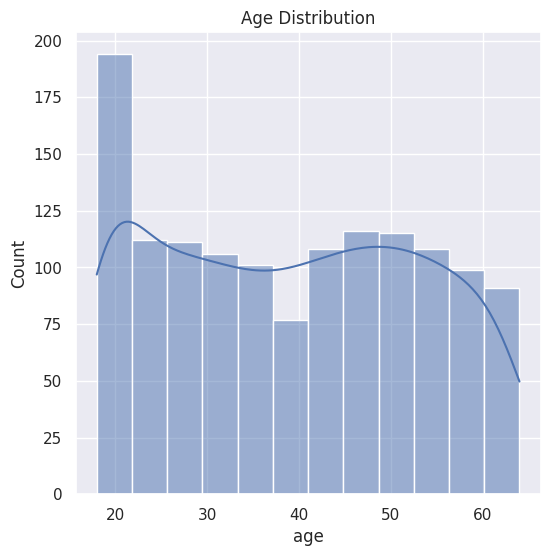

In [11]:
# distribution of age value
sns.set()
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset["age"], kde=True)
plt.title("Age Distribution")
plt.show()

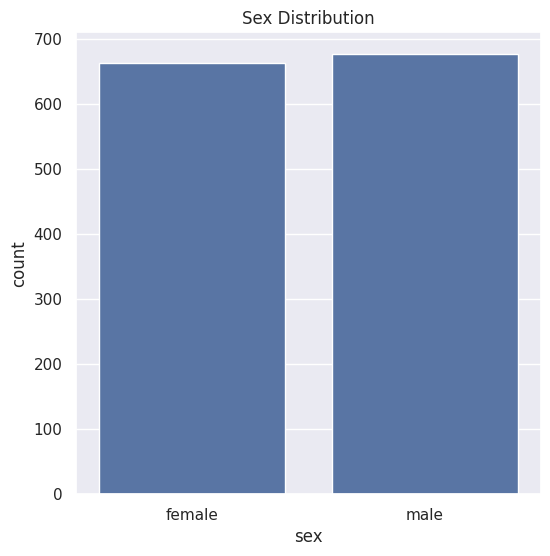

In [12]:
# gender coloumn
plt.figure(figsize=(6,6))
sns.countplot(x="sex",data=insurance_dataset)
plt.title("Sex Distribution")
plt.show()

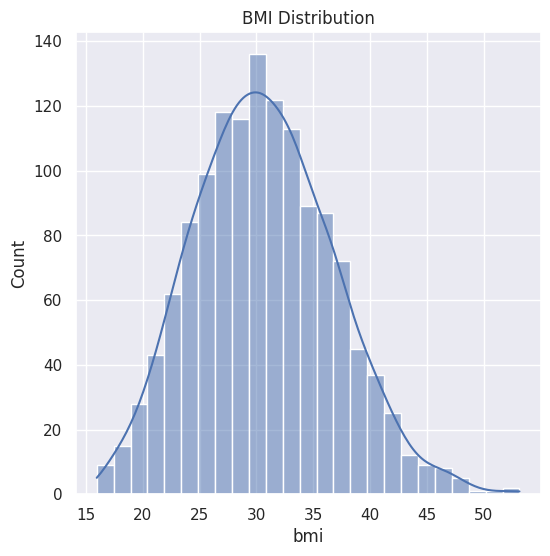

In [13]:
# bmi distribution
sns.set()
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset["bmi"], kde=True)
plt.title ("BMI Distribution")
plt.show()

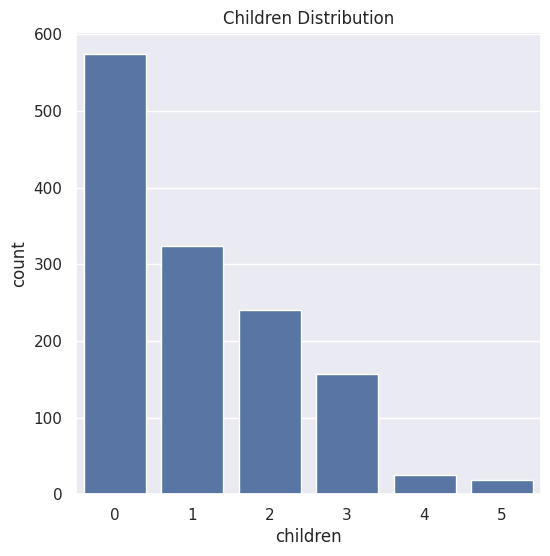

In [14]:
# children coloum
plt.figure(figsize=(6,6))
sns.countplot(x="children",data=insurance_dataset)
plt.title("Children Distribution")
plt.show()

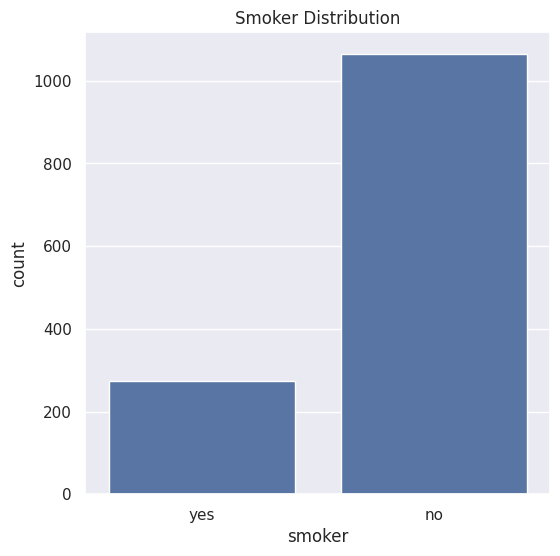

In [15]:
# smoker coloum
plt.figure(figsize=(6,6))
sns.countplot(x="smoker",data=insurance_dataset)
plt.title("Smoker Distribution")
plt.show()

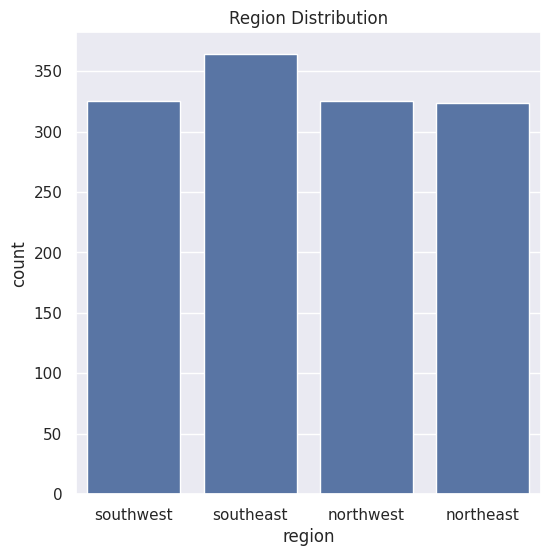

In [16]:
# region coloum
plt.figure(figsize=(6,6))
sns.countplot(x="region",data=insurance_dataset)
plt.title("Region Distribution")
plt.show()

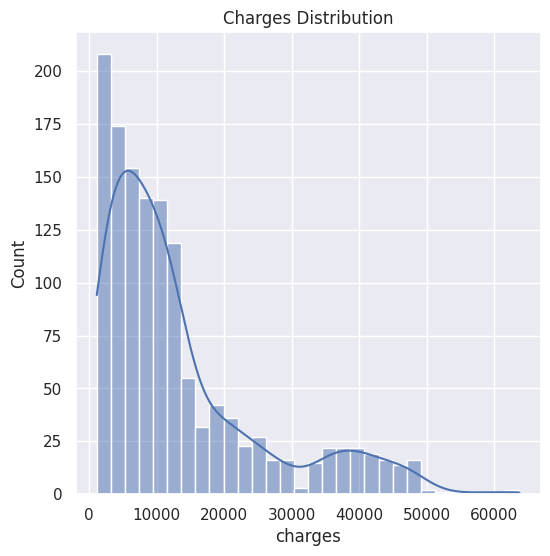

In [17]:
# distribution of charges coloumn
sns.set()
plt.figure(figsize=(6,6))
sns.histplot(insurance_dataset["charges"], kde=True)
plt.title("Charges Distribution")
plt.show()

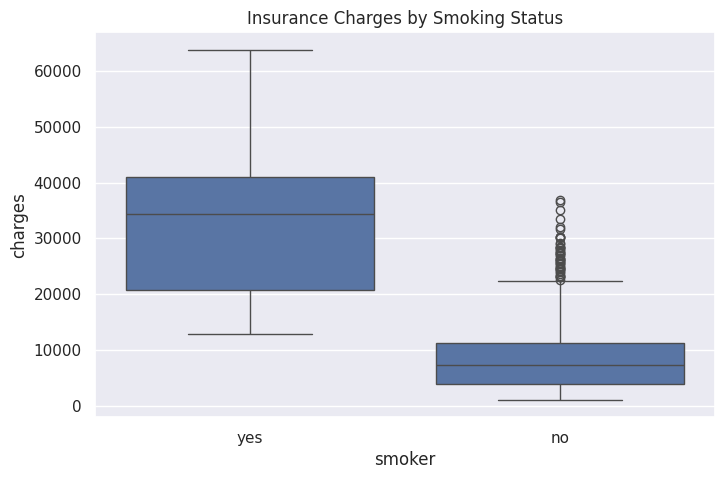

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="smoker", y="charges", data=insurance_dataset)
plt.title("Insurance Charges by Smoking Status")
plt.show()

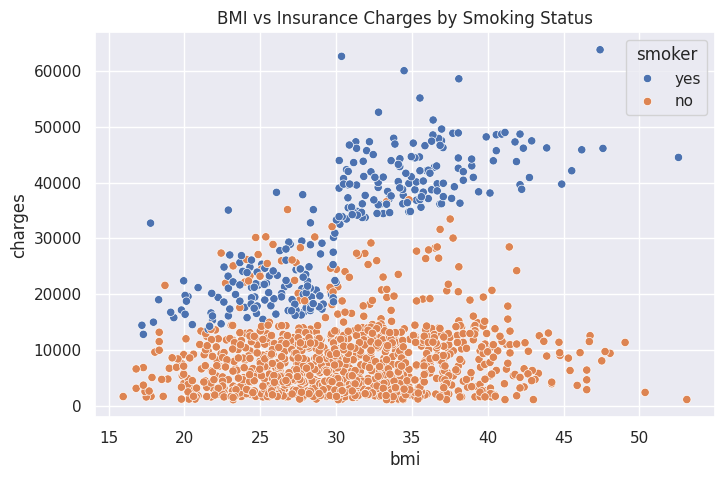

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=insurance_dataset)
plt.title("BMI vs Insurance Charges by Smoking Status")
plt.show()

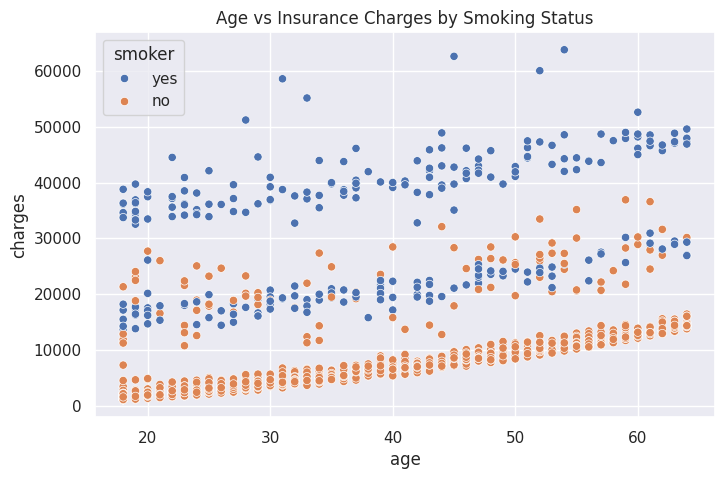

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=insurance_dataset)
plt.title("Age vs Insurance Charges by Smoking Status")
plt.show()

Data Pre-Processing

In [21]:
print(insurance_dataset['sex'].value_counts(),
insurance_dataset['children'].value_counts(),
insurance_dataset['smoker'].value_counts(),
insurance_dataset['region'].value_counts())

sex
male      676
female    662
Name: count, dtype: int64 children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64 smoker
no     1064
yes     274
Name: count, dtype: int64 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [22]:
insurance_dataset.replace({'sex':{"male":0,"female":1},
 "smoker":{"yes":0,"no":1},
"region":{"southeast":0,"southwest":1,"northwest":3,"northeast":2}},inplace=True)

/tmp/ipykernel_7745/3697100694.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_dataset.replace({'sex':{"male":0,"female":1},


In [23]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


In [24]:
X = insurance_dataset.drop(columns="charges",axis=1)
Y = insurance_dataset["charges"]

In [25]:
print(X.shape)
print(Y.shape)

(1338, 6)
(1338,)


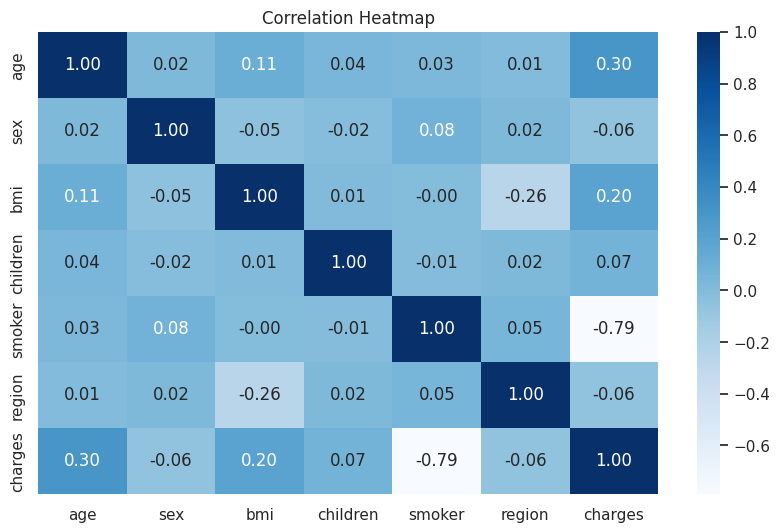

In [26]:
plt.figure(figsize=(10, 6))
sns.heatmap(insurance_dataset.corr(), fmt=".2f",annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [28]:
model = LinearRegression()

In [29]:
print(X.shape,X_test.shape,X_train.shape)

(1338, 6) (268, 6) (1070, 6)


In [30]:
model.fit(X_train,Y_train)

LinearRegression()

In [31]:
training_data_prediction  = model.predict(X_train)

In [32]:
print("Training Data Evaluation")
print("MAE :", metrics.mean_absolute_error(Y_train, training_data_prediction))
print("MSE :", metrics.mean_squared_error(Y_train, training_data_prediction))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_train, training_data_prediction)))
print("R2  :", metrics.r2_score(Y_train, training_data_prediction))

Training Data Evaluation
MAE : 4150.500304883777
MSE : 36174978.427092075
RMSE: 6014.563860089282
R2  : 0.751505643411174


In [33]:
test_data_prediction = model.predict(X_test)

In [34]:
print("Test Data Evaluation")
print("MAE :", metrics.mean_absolute_error(Y_test, test_data_prediction))
print("MSE :", metrics.mean_squared_error(Y_test, test_data_prediction))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, test_data_prediction)))
print("R2  :", metrics.r2_score(Y_test, test_data_prediction))

Test Data Evaluation
MAE : 4267.213826730733
MSE : 38337035.48643885
RMSE: 6191.690842285236
R2  : 0.7447273869684076


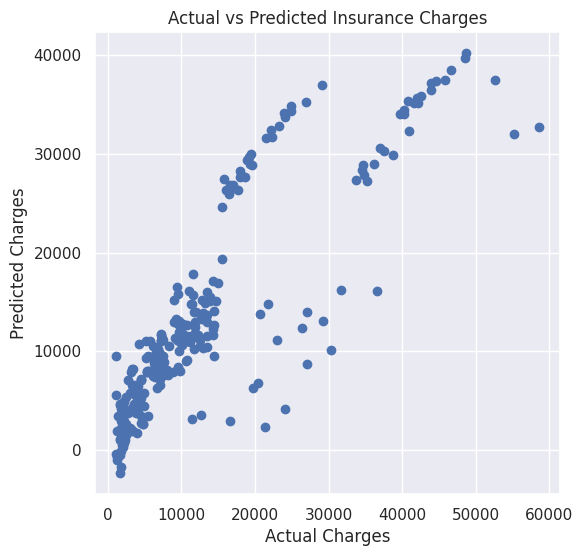

In [35]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

In [36]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, Y_train)

rf_prediction = rf_model.predict(X_test)

print("Random Forest Test Evaluation")
print("MAE :", metrics.mean_absolute_error(Y_test, rf_prediction))
print("MSE :", metrics.mean_squared_error(Y_test, rf_prediction))
print("RMSE:", np.sqrt(metrics.mean_squared_error(Y_test, rf_prediction)))
print("R2  :", metrics.r2_score(Y_test, rf_prediction))

Random Forest Test Evaluation
MAE : 2752.505484245075
MSE : 24341319.02581295
RMSE: 4933.692230552383
R2  : 0.8379198591254433


In [37]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        metrics.r2_score(Y_test, test_data_prediction),
        metrics.r2_score(Y_test, rf_prediction)
    ],
    "MAE": [
        metrics.mean_absolute_error(Y_test, test_data_prediction),
        metrics.mean_absolute_error(Y_test, rf_prediction)
    ],
    "RMSE": [
        np.sqrt(metrics.mean_squared_error(Y_test, test_data_prediction)),
        np.sqrt(metrics.mean_squared_error(Y_test, rf_prediction))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.744727,4267.213827,6191.690842
1,Random Forest,0.837920,2752.505484,4933.692231


In [38]:
input_data = (X.iloc[23])
print(input_data)
input_data_as_numpy = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy.reshape(1,-1)

prediction = rf_model.predict(input_data_reshaped)

print(prediction)

age         34.00
sex          1.00
bmi         31.92
children     1.00
smoker       0.00
region       2.00
Name: 23, dtype: float64
[38511.7019625]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## Conclusion

In this project, medical insurance cost prediction was performed using machine learning.

- The dataset contained 1338 records and 7 columns.
- There were no missing values in the dataset.
- Categorical features such as sex, smoker status, and region were encoded.
- Exploratory Data Analysis showed that smoker status has a strong impact on insurance charges.
- Linear Regression and Random Forest Regressor were trained and compared.
- Random Forest Regressor achieved the best performance with a test R² score of approximately 0.84.
- Therefore, Random Forest Regressor was selected as the final model.
- The final model can be used in a Streamlit web application for interactive insurance cost prediction.

In [39]:
import pickle

with open("insurance_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)